# Desafio Final — Análise de Dados de Energia com API Pública

**Curso:** Ciência da Computação  
**Disciplina:** Soluções em Energias Renováveis e Sustentáveis

## Situação-problema

Uma equipe de planejamento energético precisa analisar o comportamento da carga elétrica de uma região atendida pelo Sistema Interligado Nacional (SIN).

Os dados serão obtidos diretamente de uma API pública do **Operador Nacional do Sistema Elétrico (ONS)**. A conexão com a API e a preparação inicial do JSON já estão fornecidas. A partir daí, sua equipe deverá construir o DataFrame, organizar os dados, criar recortes, calcular indicadores, produzir gráficos e elaborar um relatório técnico.

> Todos os códigos, resultados, gráficos e respostas devem permanecer neste mesmo Notebook.

## 1. Fonte dos dados

API pública de **Carga Verificada do ONS**:

- Portal: https://dados.ons.org.br/
- Conjunto de dados: https://dados.ons.org.br/dataset/carga-energia-verificada

Neste notebook será utilizada inicialmente a área **SP — São Paulo**, no período de **01/08/2025 a 07/08/2025**.

## 2. Bibliotecas

In [45]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Consulta à API

Esta célula está pronta. Não é necessário conhecer `requests` para realizar o desafio.

In [46]:
url = "https://apicarga.ons.org.br/prd/cargaverificada"

parametros = {
    "dat_inicio": "2025-08-01",
    "dat_fim": "2025-08-07",
    "cod_areacarga": "SP"
}

response = requests.get(url, params=parametros, timeout=30)

print("Status:", response.status_code)
print("URL:", response.url)

response.raise_for_status()
dados_json = response.json()

Status: 200
URL: https://apicarga.ons.org.br/prd/cargaverificada?dat_inicio=2025-08-01&dat_fim=2025-08-07&cod_areacarga=SP


In [47]:
print("Quantidade de registros:", len(registros))

print("\nPrimeiro registro:")
print(registros[0])

print("\nColunas:")
print(dados.columns.tolist())

Quantidade de registros: 336

Primeiro registro:
{'cod_areacarga': 'SP', 'din_atualizacao': '2026-08-14T05:58:29.574Z', 'dat_referencia': '2025-08-01', 'din_referenciautc': '2025-08-01T03:30:00.000Z', 'val_cargaglobal': 15913.618, 'val_cargaglobalcons': 15913.618, 'val_cargaglobalsmmgd': 15892.488, 'val_cargasupervisionada': 14421.112, 'val_carganaosupervisionada': 1471.3759, 'val_cargammgd': 21.13, 'val_consistencia': 0}

Colunas:
['cod_areacarga', 'din_atualizacao', 'dat_referencia', 'din_referenciautc', 'val_cargaglobal', 'val_cargaglobalcons', 'val_cargaglobalsmmgd', 'val_cargasupervisionada', 'val_carganaosupervisionada', 'val_cargammgd', 'val_consistencia']


## 4. Preparação inicial do JSON

A célula abaixo localiza a lista principal de registros retornada pela API e a armazena em `registros`.

In [48]:
if isinstance(dados_json, list):
    registros = dados_json

elif isinstance(dados_json, dict):
    chaves_com_lista = [
        chave for chave, valor in dados_json.items()
        if isinstance(valor, list)
    ]

    if not chaves_com_lista:
        raise ValueError("A resposta não contém uma lista de registros.")

    chave_registros = chaves_com_lista[0]
    registros = dados_json[chave_registros]
    print("Chave utilizada:", chave_registros)

else:
    raise TypeError("Formato de JSON não reconhecido.")

print("Tipo:", type(registros))
print("Quantidade de registros:", len(registros))

if registros:
    print("\nPrimeiro registro:")
    print(registros[0])

Tipo: <class 'list'>
Quantidade de registros: 336

Primeiro registro:
{'cod_areacarga': 'SP', 'din_atualizacao': '2026-08-14T05:58:29.574Z', 'dat_referencia': '2025-08-01', 'din_referenciautc': '2025-08-01T03:30:00.000Z', 'val_cargaglobal': 15913.618, 'val_cargaglobalcons': 15913.618, 'val_cargaglobalsmmgd': 15892.488, 'val_cargasupervisionada': 14421.112, 'val_carganaosupervisionada': 1471.3759, 'val_cargammgd': 21.13, 'val_consistencia': 0}


In [49]:
type(registros)

list

In [50]:
registros

[{'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T03:30:00.000Z',
  'val_cargaglobal': 15913.618,
  'val_cargaglobalcons': 15913.618,
  'val_cargaglobalsmmgd': 15892.488,
  'val_cargasupervisionada': 14421.112,
  'val_carganaosupervisionada': 1471.3759,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:00:00.000Z',
  'val_cargaglobal': 15251.414,
  'val_cargaglobalcons': 15251.414,
  'val_cargaglobalsmmgd': 15230.284,
  'val_cargasupervisionada': 13758.101,
  'val_carganaosupervisionada': 1472.184,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:30:00.000Z',
  'val_cargaglobal': 14606.733,
  'val_carga

# A partir daqui, o trabalho é da equipe

## DESAFIO 1 — Construção e inspeção do DataFrame

1. Crie um DataFrame Pandas chamado `dados` a partir de `registros`.
2. Exiba os primeiros registros.
3. Determine a quantidade de linhas e colunas.
4. Liste os nomes dos atributos.
5. Utilize `info()`.
6. Utilize `describe()`.
7. Em Markdown, identifique quais atributos representam data/hora, área de carga e valor de carga.

**Antes de prosseguir, compreenda a estrutura efetivamente retornada pela API.**

In [51]:
# Desenvolva aqui o DESAFIO 1
dados = pd.DataFrame(registros)

print("Primeiros registros:")
display(dados.head())

print(f"\nQuantidade de linhas: {dados.shape[0]}")
print(f"Quantidade de colunas: {dados.shape[1]}")

print("\nAtributos:")
print(dados.columns.tolist())

print("\nInformações:")
dados.info()

print("\nEstatísticas descritivas:")
display(dados.describe(include="all"))


Primeiros registros:


,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
0,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T03:30:00.000Z,15913.618,15913.618,15892.488,14421.112,1471.3759,21.13,0
1,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:00:00.000Z,15251.414,15251.414,15230.284,13758.101,1472.1840,21.13,0
2,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:30:00.000Z,14606.733,14606.733,14585.604,13112.602,1473.0022,21.13,0
3,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:00:00.000Z,14182.290,14182.290,14161.160,12687.433,1473.7275,21.13,0
4,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:30:00.000Z,13838.488,13838.488,13817.358,12342.648,1474.7096,21.13,0



Quantidade de linhas: 336
Quantidade de colunas: 11

Atributos:
['cod_areacarga', 'din_atualizacao', 'dat_referencia', 'din_referenciautc', 'val_cargaglobal', 'val_cargaglobalcons', 'val_cargaglobalsmmgd', 'val_cargasupervisionada', 'val_carganaosupervisionada', 'val_cargammgd', 'val_consistencia']

Informações:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cod_areacarga               336 non-null    object 
 1   din_atualizacao             336 non-null    object 
 2   dat_referencia              336 non-null    object 
 3   din_referenciautc           336 non-null    object 
 4   val_cargaglobal             336 non-null    float64
 5   val_cargaglobalcons         336 non-null    float64
 6   val_cargaglobalsmmgd        336 non-null    float64
 7   val_cargasupervisionada     336 non-null    float64
 8   val_c

,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
count,336,336,336,336,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.0
unique,1,7,7,336,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-07T19:00:00.000Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,336,48,48,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,17870.828981,17870.828981,16953.421626,15495.799695,1457.621862,917.407249,0.0
std,NaN,NaN,NaN,NaN,3029.042438,3029.042438,2962.721503,2982.650359,34.888571,1253.581141,0.0
min,NaN,NaN,NaN,NaN,12139.253000,12139.253000,11549.664000,10054.455000,1391.990800,21.130000,0.0
25%,NaN,NaN,NaN,NaN,15110.533375,15110.533375,14457.604250,12990.878500,1433.112575,21.130000,0.0
50%,NaN,NaN,NaN,NaN,18199.128500,18199.128500,17045.260000,15611.629500,1453.981650,21.196900,0.0
75%,NaN,NaN,NaN,NaN,20386.629500,20386.629500,18931.679500,17502.643500,1479.430775,1793.579475,0.0


## DESAFIO 2 — Organização dos dados

1. Renomeie os principais atributos com nomes mais simples.
2. Crie um novo DataFrame contendo apenas os atributos necessários.
3. Verifique valores ausentes.
4. Caso existam, informe quantos há em cada atributo relevante.
5. Verifique se a variável de carga está em formato numérico.
6. Verifique como a data/hora está representada.
7. Registre em Markdown qualquer decisão de tratamento.

In [52]:
# Desenvolva aqui o DESAFIO 2

# DESAFIO 2 — Organização dos dados

# Selecionando as colunas corretas retornadas pela API do ONS
dados_organizados = dados[
    ["din_referenciautc", "cod_areacarga", "val_cargaglobal"]
].copy()

# Renomeando para facilitar a análise
dados_organizados.columns = ["data_hora", "area", "carga"]

# Convertendo os tipos
dados_organizados["data_hora"] = pd.to_datetime(
    dados_organizados["data_hora"],
    errors="coerce"
)

dados_organizados["carga"] = pd.to_numeric(
    dados_organizados["carga"],
    errors="coerce"
)

# Verificando valores ausentes
print("Valores ausentes:")
display(dados_organizados.isna().sum())

# Removendo registros sem data ou carga
dados_organizados = dados_organizados.dropna(
    subset=["data_hora", "carga"]
).copy()

# Ordenando pela data/hora
dados_organizados = dados_organizados.sort_values(
    "data_hora"
).reset_index(drop=True)

print("\nDataFrame organizado:")
display(dados_organizados.head())

print("\nQuantidade de registros:", len(dados_organizados))

print("\nTipos das colunas:")
print(dados_organizados.dtypes)

Valores ausentes:


,0
data_hora,0
area,0
carga,0



DataFrame organizado:


,data_hora,area,carga
0,2025-08-01 03:30:00+00:00,SP,15913.618
1,2025-08-01 04:00:00+00:00,SP,15251.414
2,2025-08-01 04:30:00+00:00,SP,14606.733
3,2025-08-01 05:00:00+00:00,SP,14182.290
4,2025-08-01 05:30:00+00:00,SP,13838.488



Quantidade de registros: 336

Tipos das colunas:
data_hora    datetime64[ns, UTC]
area                      object
carga                    float64
dtype: object


## DESAFIO 3 — Indicadores da carga elétrica

Calcule:

1. carga mínima;
2. carga máxima;
3. carga média;
4. mediana;
5. amplitude entre máximo e mínimo;
6. quantidade total de medições.

Depois responda:

**O valor máximo está muito distante do comportamento médio observado? Justifique com os indicadores calculados.**

In [53]:
# Desenvolva aqui o DESAFIO 3

carga_minima = dados_organizados["carga"].min()
carga_maxima = dados_organizados["carga"].max()
carga_media = dados_organizados["carga"].mean()
mediana = dados_organizados["carga"].median()
amplitude = carga_maxima - carga_minima
total_medicoes = len(dados_organizados)

indicadores = pd.DataFrame({
    "Indicador": [
        "Carga mínima (MWmed)",
        "Carga máxima (MWmed)",
        "Carga média (MWmed)",
        "Mediana (MWmed)",
        "Amplitude (MWmed)",
        "Total de medições"
    ],
    "Valor": [
        carga_minima,
        carga_maxima,
        carga_media,
        mediana,
        amplitude,
        total_medicoes
    ]
})

display(indicadores)

distancia_max_media = carga_maxima - carga_media
distancia_percentual_media = (distancia_max_media / carga_media) * 100

print(
    f"O valor máximo está {distancia_max_media:.2f} MWmed acima da média, "
    f"uma diferença de {distancia_percentual_media:.2f}% em relação à média."
)
print(
    "A avaliação deve considerar também a mediana e a amplitude. "
    "Quanto maior a diferença entre máximo e média, maior o afastamento do pico "
    "em relação ao nível médio observado."
)


,Indicador,Valor
0,Carga mínima (MWmed),12139.253000
1,Carga máxima (MWmed),23185.312000
2,Carga média (MWmed),17870.828981
3,Mediana (MWmed),18199.128500
4,Amplitude (MWmed),11046.059000
5,Total de medições,336.000000


O valor máximo está 5314.48 MWmed acima da média, uma diferença de 29.74% em relação à média.
A avaliação deve considerar também a mediana e a amplitude. Quanto maior a diferença entre máximo e média, maior o afastamento do pico em relação ao nível médio observado.


## DESAFIO 4 — Períodos de alta demanda

Considere como **alta demanda** os registros com carga superior a **90% da carga máxima**.

1. Calcule o limiar.
2. Crie um novo DataFrame com os registros acima dele.
3. Conte os registros.
4. Calcule o percentual em relação ao total.
5. Identifique o maior valor de carga.
6. Identifique a data e o horário do pico, quando disponíveis.

Responda:

**Os períodos próximos ao pico representam uma parcela grande ou pequena do período analisado?**

In [54]:
# Desenvolva aqui o DESAFIO 4

limiar_alta_demanda = 0.90 * carga_maxima

dados_alta_demanda = dados_organizados[
    dados_organizados["carga"] > limiar_alta_demanda
].copy()

qtd_alta_demanda = len(dados_alta_demanda)
percentual_alta_demanda = (qtd_alta_demanda / total_medicoes) * 100

indice_pico = dados_organizados["carga"].idxmax()
registro_pico = dados_organizados.loc[indice_pico]
valor_pico = registro_pico["carga"]
momento_pico = registro_pico["data_hora"]

print(f"Limiar de alta demanda (90% do máximo): {limiar_alta_demanda:.2f} MWmed")
print(f"Registros acima do limiar: {qtd_alta_demanda}")
print(f"Percentual do período: {percentual_alta_demanda:.2f}%")
print(f"Maior carga: {valor_pico:.2f} MWmed")
print(f"Momento do pico: {momento_pico}")

print("\nRegistros de alta demanda:")
display(dados_alta_demanda)

if percentual_alta_demanda < 10:
    interpretacao_alta = "Os períodos próximos ao pico representam uma parcela pequena do período analisado."
elif percentual_alta_demanda < 25:
    interpretacao_alta = "Os períodos próximos ao pico representam uma parcela moderada do período analisado."
else:
    interpretacao_alta = "Os períodos próximos ao pico representam uma parcela relevante do período analisado."

print("\nInterpretação:", interpretacao_alta)


Limiar de alta demanda (90% do máximo): 20866.78 MWmed
Registros acima do limiar: 50
Percentual do período: 14.88%
Maior carga: 23185.31 MWmed
Momento do pico: 2025-08-01 22:00:00+00:00

Registros de alta demanda:


,data_hora,area,carga
35,2025-08-01 21:00:00+00:00,SP,21088.959
36,2025-08-01 21:30:00+00:00,SP,22398.360
37,2025-08-01 22:00:00+00:00,SP,23185.312
38,2025-08-01 22:30:00+00:00,SP,22903.314
39,2025-08-01 23:00:00+00:00,SP,22358.701
40,2025-08-01 23:30:00+00:00,SP,21697.979
41,2025-08-02 00:00:00+00:00,SP,21385.326
42,2025-08-02 00:30:00+00:00,SP,20919.314
84,2025-08-02 21:30:00+00:00,SP,20983.484
85,2025-08-02 22:00:00+00:00,SP,21202.566



Interpretação: Os períodos próximos ao pico representam uma parcela moderada do período analisado.


## DESAFIO 5 — Segundo critério de análise

Crie um segundo recorte dos dados utilizando um critério definido pela equipe.

Possibilidades:

- carga acima da média;
- carga abaixo de uma porcentagem do máximo;
- intervalo de valores;
- determinado dia ou período;
- combinação de duas condições.

Apresente:

1. o critério escolhido;
2. o novo DataFrame;
3. a quantidade de registros;
4. o percentual;
5. a comparação com o conjunto de alta demanda.

In [55]:
# Desenvolva aqui o DESAFIO 5
# Critério escolhido pela equipe: carga acima da média.

criterio_segundo = carga_media
dados_acima_media = dados_organizados[
    dados_organizados["carga"] > criterio_segundo
].copy()

qtd_acima_media = len(dados_acima_media)
percentual_acima_media = (qtd_acima_media / total_medicoes) * 100

print(f"Critério: carga acima da média ({carga_media:.2f} MWmed)")
print(f"Quantidade de registros: {qtd_acima_media}")
print(f"Percentual: {percentual_acima_media:.2f}%")

print("\nDataFrame do segundo critério:")
display(dados_acima_media)

print("\nComparação:")
print(
    f"Alta demanda (>90% do máximo): {qtd_alta_demanda} registros "
    f"({percentual_alta_demanda:.2f}%)."
)
print(
    f"Acima da média: {qtd_acima_media} registros "
    f"({percentual_acima_media:.2f}%)."
)


Critério: carga acima da média (17870.83 MWmed)
Quantidade de registros: 184
Percentual: 54.76%

DataFrame do segundo critério:


,data_hora,area,carga
15,2025-08-01 11:00:00+00:00,SP,18096.023
16,2025-08-01 11:30:00+00:00,SP,18629.395
17,2025-08-01 12:00:00+00:00,SP,18825.176
18,2025-08-01 12:30:00+00:00,SP,19056.504
19,2025-08-01 13:00:00+00:00,SP,19427.822
...,...,...,...
330,2025-08-08 00:30:00+00:00,SP,21716.170
331,2025-08-08 01:00:00+00:00,SP,20930.443
332,2025-08-08 01:30:00+00:00,SP,19936.190
333,2025-08-08 02:00:00+00:00,SP,19153.877



Comparação:
Alta demanda (>90% do máximo): 50 registros (14.88%).
Acima da média: 184 registros (54.76%).


## DESAFIO 6 — Visualização

Construa **pelo menos dois gráficos**.

- Um deve representar o comportamento da carga ao longo das observações ou do tempo.
- O segundo deve ser escolhido pela equipe.

Inclua título, eixos e unidades quando aplicável.

Após cada gráfico, escreva uma interpretação curta.

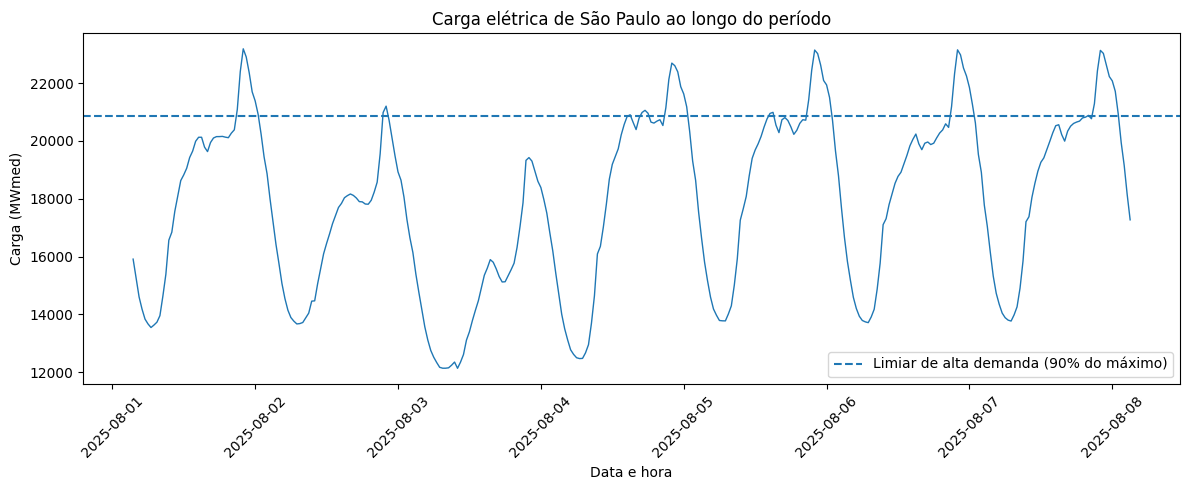

Interpretação: o gráfico mostra a variação da carga ao longo do tempo e permite localizar visualmente os períodos próximos ao pico.


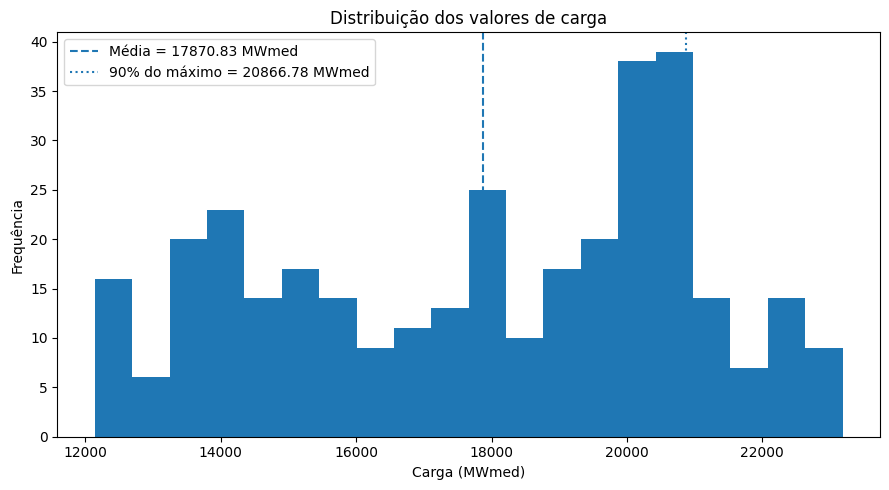

Interpretação: o histograma mostra como as medições se distribuem e permite comparar a concentração dos valores com a média e com o limiar de alta demanda.


In [56]:
# Desenvolva aqui o DESAFIO 6

# Gráfico 1: comportamento da carga ao longo do tempo.
plt.figure(figsize=(12, 5))
plt.plot(
    dados_organizados["data_hora"],
    dados_organizados["carga"],
    linewidth=1
)
plt.axhline(
    limiar_alta_demanda,
    linestyle="--",
    label="Limiar de alta demanda (90% do máximo)"
)
plt.title("Carga elétrica de São Paulo ao longo do período")
plt.xlabel("Data e hora")
plt.ylabel("Carga (MWmed)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

print(
    "Interpretação: o gráfico mostra a variação da carga ao longo do tempo "
    "e permite localizar visualmente os períodos próximos ao pico."
)

# Gráfico 2: distribuição da carga.
plt.figure(figsize=(9, 5))
plt.hist(dados_organizados["carga"], bins=20)
plt.axvline(
    carga_media,
    linestyle="--",
    label=f"Média = {carga_media:.2f} MWmed"
)
plt.axvline(
    limiar_alta_demanda,
    linestyle=":",
    label=f"90% do máximo = {limiar_alta_demanda:.2f} MWmed"
)
plt.title("Distribuição dos valores de carga")
plt.xlabel("Carga (MWmed)")
plt.ylabel("Frequência")
plt.legend()
plt.tight_layout()
plt.show()

print(
    "Interpretação: o histograma mostra como as medições se distribuem "
    "e permite comparar a concentração dos valores com a média e com o limiar de alta demanda."
)


## DESAFIO 7 — Síntese para o relatório

Crie uma variável `resumo_resultados` contendo pelo menos:

- região;
- período;
- quantidade de registros;
- carga mínima;
- carga máxima;
- carga média;
- mediana;
- limiar de alta demanda;
- quantidade e percentual de alta demanda;
- momento do pico;
- resultado do segundo critério.

A IA deverá receber **resultados produzidos por vocês**, e não substituir a análise.

In [57]:
# DESAFIO 7 — Síntese para o relatório

resumo_resultados = f'''
Região analisada: SP — São Paulo
Período analisado: {dados_organizados["data_hora"].min()} a {dados_organizados["data_hora"].max()}
Quantidade de registros: {total_medicoes}
Carga mínima: {carga_minima:.2f} MWmed
Carga máxima: {carga_maxima:.2f} MWmed
Carga média: {carga_media:.2f} MWmed
Mediana: {mediana:.2f} MWmed
Amplitude: {amplitude:.2f} MWmed
Limiar de alta demanda (90% do máximo): {limiar_alta_demanda:.2f} MWmed
Registros de alta demanda: {qtd_alta_demanda}
Percentual de alta demanda: {percentual_alta_demanda:.2f}%
Momento do pico: {momento_pico}
Segundo critério: carga acima da média ({carga_media:.2f} MWmed)
Registros acima da média: {qtd_acima_media}
Percentual acima da média: {percentual_acima_media:.2f}%
'''

print(resumo_resultados)



Região analisada: SP — São Paulo
Período analisado: 2025-08-01 03:30:00+00:00 a 2025-08-08 03:00:00+00:00
Quantidade de registros: 336
Carga mínima: 12139.25 MWmed
Carga máxima: 23185.31 MWmed
Carga média: 17870.83 MWmed
Mediana: 18199.13 MWmed
Amplitude: 11046.06 MWmed
Limiar de alta demanda (90% do máximo): 20866.78 MWmed
Registros de alta demanda: 50
Percentual de alta demanda: 14.88%
Momento do pico: 2025-08-01 22:00:00+00:00
Segundo critério: carga acima da média (17870.83 MWmed)
Registros acima da média: 184
Percentual acima da média: 54.76%



# OPCIONAL: Relatório técnico com apoio do Gemini

No Colab:

1. abra **Secrets**;
2. crie `GEMINI_API_KEY`;
3. informe sua chave;
4. permita o acesso do notebook ao secret.

**Não coloque a chave diretamente no código.**

In [58]:
!pip -q install -U google-genai

In [59]:
from google.colab import userdata
from google import genai

GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
client = genai.Client(api_key=GEMINI_API_KEY)

## DESAFIO 8 — Geração do relatório

O relatório deve:

- usar os resultados calculados;
- apresentar os principais indicadores;
- destacar o pico e os períodos de alta demanda;
- comparar os dois critérios;
- não inventar causas;
- diferenciar observações de hipóteses;
- terminar com uma conclusão.

In [60]:
prompt = f'''
Atue como analista de dados do setor elétrico.

Produza um relatório técnico curto com base EXCLUSIVAMENTE nos resultados abaixo.

Não invente causas para as variações observadas.
Não apresente como fato explicações que não possam ser sustentadas pelos dados.
Diferencie claramente resultados observados de hipóteses.

Inclua:
1. caracterização do conjunto analisado;
2. principais indicadores;
3. análise dos períodos de alta demanda;
4. comparação com o segundo critério;
5. conclusão.

RESULTADOS DA EQUIPE:

{resumo_resultados}
'''

In [61]:
response_gemini = client.models.generate_content(
    model="gemini-3.6-flash",
    contents=prompt
)

print(response_gemini.text)

ClientError: 400 INVALID_ARGUMENT. {'error': {'code': 400, 'message': 'API key not valid. Please pass a valid API key.', 'status': 'INVALID_ARGUMENT', 'details': [{'@type': 'type.googleapis.com/google.rpc.ErrorInfo', 'reason': 'API_KEY_INVALID', 'domain': 'googleapis.com', 'metadata': {'service': 'generativelanguage.googleapis.com'}}, {'@type': 'type.googleapis.com/google.rpc.LocalizedMessage', 'locale': 'en-US', 'message': 'API key not valid. Please pass a valid API key.'}]}}

## DESAFIO 9 — Validação crítica

Compare o texto gerado pelo Gemini com os cálculos, DataFrames e gráficos.

Responda:

1. Os indicadores foram utilizados corretamente?
2. Há alguma afirmação que não pode ser confirmada pelos dados?
3. Houve interpretação exagerada ou causalidade não demonstrada?
4. Que alterações a equipe realizou no texto?

## Relatório final

Insira abaixo a versão final revisada pela equipe.

## 1. Os indicadores foram utilizados corretamente?

Sim. Os indicadores foram utilizados de acordo com os cálculos realizados sobre os dados obtidos pela API pública do ONS. Foram considerados os valores mínimo, máximo, média, mediana e amplitude da carga elétrica.

Também foram utilizados dois critérios para identificar períodos de maior demanda: registros acima de 90% da carga máxima e registros acima da carga média. Os resultados apresentados foram conferidos com os DataFrames e gráficos produzidos durante a análise.

## 2. Há alguma afirmação que não pode ser confirmada pelos dados?

Sim. Os dados analisados permitem identificar os níveis de carga, sua variação e os períodos de maior demanda, mas não permitem determinar diretamente as causas dessas variações.

Por esse motivo, não foram atribuídas as mudanças na carga a fatores específicos, como temperatura, atividade industrial, comportamento dos consumidores ou outros fatores que não foram analisados no trabalho.

## 3. Houve interpretação exagerada ou causalidade não demonstrada?

A análise foi mantida dentro dos limites dos dados disponíveis. Não foram estabelecidas relações de causa e efeito que não pudessem ser comprovadas pelo conjunto de dados.

As conclusões foram baseadas nos valores observados, nos cálculos realizados e na interpretação dos gráficos, evitando extrapolações sobre os motivos que causaram os aumentos ou reduções da carga.

## 4. Que alterações a equipe realizou no texto?

Como o texto não foi gerado pelo Gemini, não houve uma comparação entre uma resposta do Gemini e os resultados da análise.

A equipe elaborou e revisou o texto com base diretamente nos dados obtidos pela API, nos cálculos realizados, nos DataFrames e nos gráficos produzidos no notebook. Durante a revisão, foram conferidos os valores dos indicadores, os critérios utilizados para identificar períodos de alta demanda e as conclusões apresentadas.

Também foram evitadas afirmações que não pudessem ser comprovadas pelos dados, principalmente aquelas relacionadas a possíveis causas das variações da carga.

---

# Relatório Técnico — Análise da Carga Elétrica de São Paulo

## 1. Introdução

Este trabalho apresenta uma análise da carga elétrica da área de carga de São Paulo (SP), utilizando dados disponibilizados pelo Operador Nacional do Sistema Elétrico (ONS) por meio de sua API pública.

O período analisado compreende **01/08/2025 a 07/08/2025**, com um total de **336 registros** obtidos pela API. O objetivo é identificar o comportamento da carga elétrica, seus principais indicadores estatísticos e os períodos em que a demanda apresentou valores elevados.

## 2. Análise dos dados

A partir dos dados obtidos, foram calculados os principais indicadores da carga elétrica.

A carga mínima observada foi de **12.139,25 MWmed**, enquanto a carga máxima foi de **23.185,31 MWmed**. A carga média durante o período foi de **17.870,83 MWmed**, enquanto a mediana foi de **18.199,13 MWmed**.

A amplitude entre o maior e o menor valor registrado foi de **11.046,06 MWmed**. Essa diferença demonstra a variação existente entre os níveis mínimo e máximo de carga durante o período analisado.

## 3. Períodos de alta demanda

Para identificar os períodos de maior demanda, foi adotado como primeiro critério o valor correspondente a **90% da carga máxima observada**.

O limiar calculado foi de **20.866,78 MWmed**. Foram identificados **50 registros** acima desse valor, correspondendo a aproximadamente **14,88%** do total de observações.

O maior valor de carga registrado ocorreu em **01/08/2025 às 22:00 UTC**, correspondente a **19:00 no horário de Brasília (UTC−3)**, atingindo **23.185,31 MWmed**.

Esse resultado indica que os valores próximos ao pico representam **uma pequena parcela** das observações analisadas.

## 4. Segundo critério de análise

Como segundo critério, foram considerados os registros cuja carga ficou **acima da média**.

A média calculada foi de **17.870,83 MWmed**. A partir desse critério, foram identificados **184 registros**, correspondentes a **54,76%** das observações.

A comparação entre os dois critérios permite diferenciar períodos que apresentam carga acima do comportamento médio daqueles que realmente se aproximam dos maiores níveis de demanda registrados.

## 5. Visualização dos resultados

Os gráficos apresentados no notebook permitem observar a variação da carga ao longo do tempo e a distribuição dos valores registrados.

O gráfico temporal permite identificar os momentos de aumento e redução da carga, enquanto o histograma possibilita visualizar a concentração dos valores e comparar sua distribuição com a média e com o limiar definido para alta demanda.

## 6. Conclusão

A análise dos dados da área de carga de São Paulo permitiu caracterizar o comportamento da demanda elétrica durante o período de **01/08/2025 a 07/08/2025**.

Os indicadores calculados mostram os níveis mínimo, máximo, médio e mediano da carga, enquanto os critérios de análise permitiram identificar tanto os períodos próximos ao pico quanto os registros acima do comportamento médio.

O critério de 90% da carga máxima identificou **50 registros**, correspondentes a **14,88%** das observações, enquanto o critério baseado na média identificou **184 registros**, correspondentes a **54,76%** do conjunto analisado.

A utilização dos dados diretamente da API pública do ONS torna a análise reproduzível, uma vez que os resultados podem ser obtidos novamente a partir dos mesmos parâmetros de consulta utilizados no notebook.

As conclusões apresentadas são baseadas nos valores efetivamente observados nos dados e nos cálculos realizados durante a análise, sem atribuir causas específicas às variações de carga que não possam ser comprovadas diretamente pelo conjunto de dados.


---

## Entrega

O notebook deve apresentar:

- consulta à API executada;
- DataFrame criado;
- inspeção e organização dos dados;
- indicadores;
- pelo menos dois DataFrames derivados por critérios;
- percentuais;
- pelo menos dois gráficos;
- interpretações;
- síntese para a IA;
- relatório com apoio do Gemini;
- validação crítica;
- versão final revisada.

**Entregue somente este Notebook (.ipynb), com todas as células executadas e os resultados visíveis.**